In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("21-housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


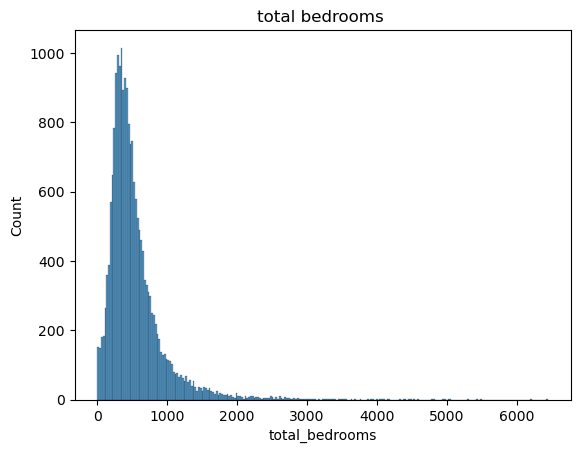

In [5]:
sns.histplot(df['total_bedrooms'])
plt.title("total bedrooms ")
plt.show()

In [6]:
df["total_bedrooms"].fillna(df["total_bedrooms"].median(),inplace=True)

C:\Users\Ömer faruk\AppData\Local\Temp\ipykernel_12148\1599158251.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(),inplace=True)


In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [8]:
cols=['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']


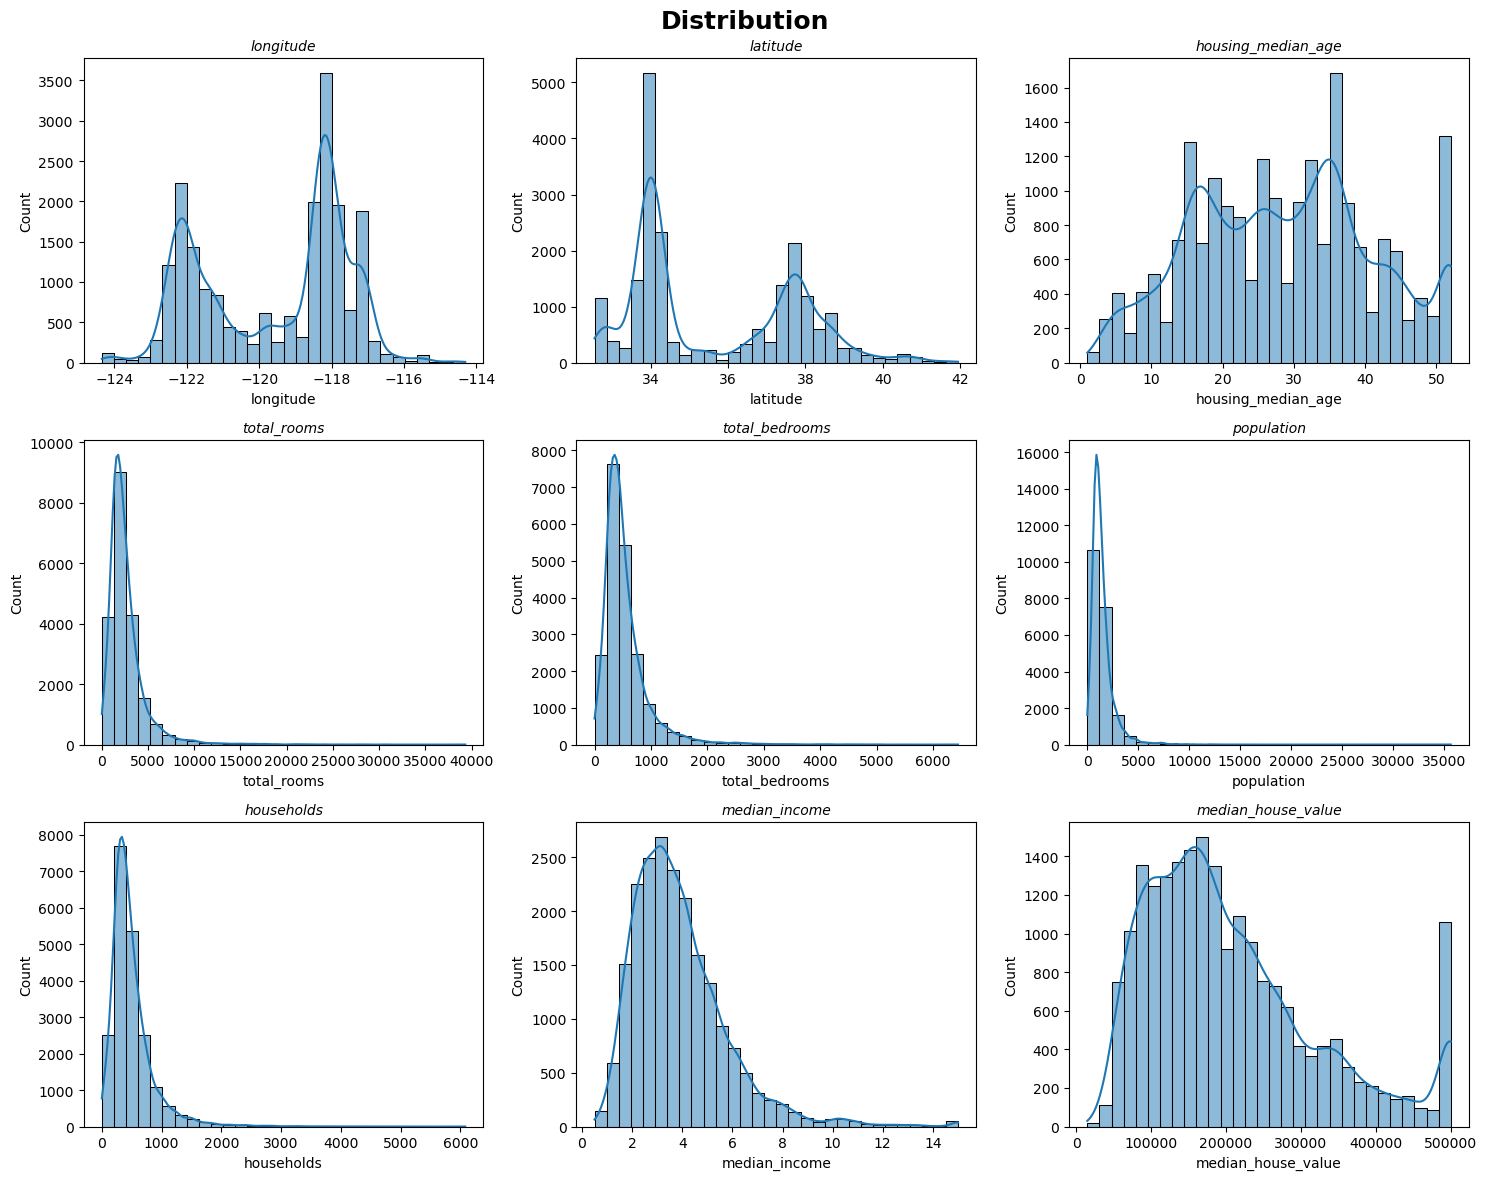

In [9]:
fig,axes=plt.subplots(nrows=3,ncols=3,figsize=(15,12))
fig.suptitle("Distribution",fontsize=18,fontweight="bold")

for i,col in enumerate(cols):
    row=i//3
    col_idx=i%3
    ax=axes[row,col_idx]
    sns.histplot(data=df,x=col,kde=True,ax=ax,bins=30)
    ax.set_title(col,fontsize=10,fontstyle="italic")

plt.tight_layout()
plt.show()

<Axes: >

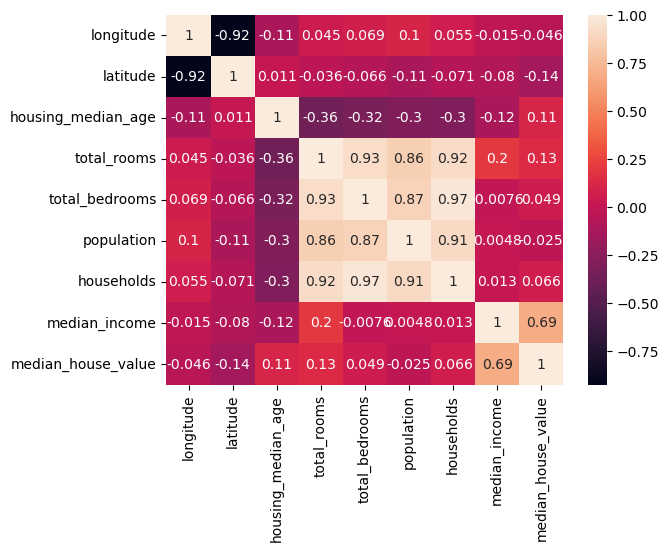

In [10]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [11]:
def find_outlier_iqr(df,threshold=1.5):
    outlier_summary={}
    numeric_cols=df.select_dtypes(include=["float64","int64"]).columns
    for col in numeric_cols:
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1

        lower_bound=Q1-threshold*IQR
        upper_bound=Q3+threshold*IQR

        outliers=df[ (df[col]<lower_bound) | (df[col]>upper_bound) ]
        outlier_summary[col]={
                "outlier_count":outliers.shape[0],
                "outlier_percentage":100*outliers.shape[0]/df.shape[0],
                "lower_bound":lower_bound,
                "upper_bound":upper_bound
                            
            
        }

    return pd.DataFrame(outlier_summary).T

In [12]:
find_outlier_iqr(df)

,outlier_count,outlier_percentage,lower_bound,upper_bound
longitude,0.0,0.000000,-127.485000,-112.325000
latitude,0.0,0.000000,28.260000,43.380000
housing_median_age,0.0,0.000000,-10.500000,65.500000
total_rooms,1287.0,6.235465,-1102.625000,5698.375000
total_bedrooms,1306.0,6.327519,-222.375000,1162.625000
population,1196.0,5.794574,-620.000000,3132.000000
households,1220.0,5.910853,-207.500000,1092.500000
median_income,681.0,3.299419,-0.706375,8.013025
median_house_value,1071.0,5.188953,-98087.500000,482412.500000


In [13]:
def remove_outlier_from_column(df,target_column,threshold=1.5):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1

    lower_bound=Q1-threshold*IQR
    upper_bound=Q3+threshold*IQR

    return df[ (df[col]>=lower_bound) & (df[col]<=upper_bound) ]


In [14]:
def remove_outlier_from_all_columns(df,threshold=1.5):
    df_clean=df.copy()
    numeric_cols=df.select_dtypes(include=["float64","int64"]).columns
    for col in numeric_cols:
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1

        lower_bound=Q1-threshold*IQR
        upper_bound=Q3+threshold*IQR

        df_clean=df_clean[ (df_clean[col]<lower_bound) | (df_clean[col]>upper_bound) ]
    return df_clean.copy()

In [15]:
df_target_clean=remove_outlier_from_column(df,"median_house_value")

In [18]:
df_target_clean=pd.get_dummies(df_target_clean,columns=["ocean_proximity"],drop_first=True,dtype='int64')

In [19]:
df_target_clean.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


In [20]:
from sklearn.model_selection import train_test_split
X=df_target_clean.drop("median_house_value",axis=1)
y=df_target_clean["median_house_value"]

In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

In [29]:
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [30]:
def evaluate_model(y_test,y_pred):
    mae=mean_absolute_error(y_test,y_pred)
    mse=mean_squared_error(y_test,y_pred)
    rmse=root_mean_squared_error(y_test,y_pred)
    r2score=r2_score(y_test,y_pred)
    return mae,mse,rmse,r2score

In [31]:
models={
        "lineer regression":LinearRegression(),
        "KNN regressor":KNeighborsRegressor(),
        "Random forest":RandomForestRegressor(),
        "Adaboost regressor":AdaBoostRegressor(),
        "Gradientboosting regressor":GradientBoostingRegressor(),
        "Ridge":Ridge(),
        "Lasso":Lasso(),
        "Decision tree":DecisionTreeRegressor(),
        "XGBoost regressor":XGBRegressor()

    
}

In [37]:
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    train_mae,train_mse,train_rmse,train_r2score=evaluate_model(y_train,y_train_pred)
    test_mae,test_mse,test_rmse,test_r2score=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    print("model performance for training")
    print(f"mae: {train_mae}---mse: {train_mse}---rmse: {train_rmse}---r^2 score: {train_r2score}\n")
    print("model performance for test")
    print(f"mae: {test_mae}---mse: {test_mse}---rmse: {test_rmse}---r^2 score: {test_r2score}\n")
    print("----------------------------------------------------------------------------------------\n")


lineer regression
model performance for training
mae: 43959.093262368406---mse: 3544020508.114414---rmse: 59531.67651019425---r^2 score: 0.6090966245427281

model performance for test
mae: 43221.86807515078---mse: 3383429830.1532173---rmse: 58167.25737176558---r^2 score: 0.6335620194918266

----------------------------------------------------------------------------------------

KNN regressor
model performance for training
mae: 56575.89423548651---mse: 5227685131.560297---rmse: 72302.73253176741---r^2 score: 0.4233894078558925

model performance for test
mae: 69344.54939709789---mse: 7668188450.187673---rmse: 87568.19314218874---r^2 score: 0.16950679313611605

----------------------------------------------------------------------------------------

Random forest
model performance for training
mae: 10961.16524597983---mse: 265936381.91397136---rmse: 16307.555976110318---r^2 score: 0.9706673736483611

model performance for test
mae: 29210.082763131---mse: 1884295853.2552497---rmse: 43408

In [33]:
X_train.shape

(14676, 12)

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
xgboost_params={
        "learning_rate":[0.001,0.01,0.1,0.2],
        "max_depth":[5,8,10,12,14,20],
        "n_estimators":[50,75,100,200],
        "colsample_bytree:":[0.3,0.4,0.5,0.6]


    
}    

In [43]:
grid_search=GridSearchCV(estimator=XGBRegressor(device="gpu"),param_grid=xgboost_params,n_jobs=-1)

In [44]:
grid_search.fit(X_train,y_train)

C:\Users\Ömer faruk\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [00:20:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "colsample_bytree:" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree:': [0.3, 0.4, ...], 'learning_rate': [0.001, 0.01, ...], 'max_depth': [5, 8, ...], 'n_estimators': [50, 75, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [46]:
grid_search.best_params_

{'colsample_bytree:': 0.3,
 'learning_rate': 0.1,
 'max_depth': 8,
 'n_estimators': 200}

In [47]:
model_new=XGBRegressor(colsample_bytree=0.3,learning_rate=0.1,max_depth=8,n_estimators=200)

In [48]:
model_new.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.3
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [51]:
y_train_pred_new=model_new.predict(X_train)
y_test_pred_new=model_new.predict(X_test)

In [52]:
train_mae,train_mse,train_rmse,train_r2score=evaluate_model(y_train,y_train_pred_new)
test_mae,test_mse,test_rmse,test_r2score=evaluate_model(y_test,y_test_pred_new)

print(list(models.keys())[i])
print("model performance for training")
print(f"mae: {train_mae}---mse: {train_mse}---rmse: {train_rmse}---r^2 score: {train_r2score}\n")
print("model performance for test")
print(f"mae: {test_mae}---mse: {test_mse}---rmse: {test_rmse}---r^2 score: {test_r2score}\n")
print("----------------------------------------------------------------------------------------\n")

XGBoost regressor
model performance for training
mae: 17610.500652771745---mse: 591660870.2132602---rmse: 24324.080048652613---r^2 score: 0.9347401543634398

model performance for test
mae: 30312.270042583154---mse: 1901232957.4691672---rmse: 43603.130133846666---r^2 score: 0.7940894298437291

----------------------------------------------------------------------------------------

